<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/OuvertureSpectreSDSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Téléchargement d'un spectre SDSS

https://skyserver.sdss.org/dr19/VisualTools/navi

# Lecture et affichage du spectre

In [2]:
# Import librairies
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from google.colab import files

In [14]:
# récupération du fichier
fichier = files.upload()

# Open the FITS file using astropy.io.fits
for filename in fichier.keys():
    print(f"Processing FITS file: {filename}")
    try:
        with fits.open(filename) as hdul:
            hdul.info()
    except Exception as e:
        print(f"Erreur avec {filename} : {e}")

Saving spec-1511-52946-0351.fits to spec-1511-52946-0351 (4).fits
Processing FITS file: spec-1511-52946-0351 (4).fits
Filename: spec-1511-52946-0351 (4).fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     141   ()      
  1  COADD         1 BinTableHDU     26   3831R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   


In [31]:
# Récupération du spectre dans le FITS

# Get the single filename from the 'fichier' dictionary
# 'fichier' contains the raw byte data, the keys are the filenames.
# Even for a single file, files.upload() returns a dictionary with the filename as a key. I

filename = list(fichier.keys())[0]
print(f"Ouverture du FITS: {filename}")

with fits.open(filename) as hdul: # This is a Python context manager for opening FITS files. It ensures that the FITS file specified by filename is properly opened and, very importantly, automatically closed when the code block inside the with statement is exited
    data = hdul[1].data  # hdul is the variable that will hold the 'HDUList' object, which is a list-like object containing all the Header Data Units (HDUs) in the FITS file.
                        # data = hdul[1].data: This line accesses the data part of the second HDU (Header Data Unit) in the FITS file. FITS files can contain multiple HDUs, with the first one often being the primary header (index 0) and subsequent HDUs holding actual data (like images, tables, or spectra). In many astronomical data files, the scientific data (like a spectrum's flux and wavelength) is stored in a binary table in the second HDU (index 1). The .data attribute retrieves this data, typically as a numpy.ndarray or astropy.table.Table
    flux = data['flux']     # assumes that the data object (which is likely a table or structured array) contains a column named 'flux'. It extracts all the values from this 'flux' column and assigns them to the flux variable
    loglam = data['loglam']      # assumes there's a column named 'loglam' in the data object. It extracts these values and assigns them to the loglam variable. 'loglam' typically stands for log10(wavelength), meaning the base-10 logarithm of the wavelength
    lam = 10**loglam    # 10 puissance log de longueur d'onde

   # print("\nHeader of HDU 0:")
   # print(repr(header_0))
    print("\nDonnées 'flux' (premières 5 colonnes):")
    print(flux[:5]) # Display first 5 rows of data for brevity
    print("\nDonnées 'loglam' (premières 5 colonnes):")
    print(loglam[:5]) # Display first 5 rows of data for brevity
    print("\nDonnées 'lam' (premières 5 colonnes):")
    print(lam[:5]) # Display first 5 rows of data for brevity


Ouverture du FITS: spec-1511-52946-0351 (4).fits

Données 'flux' (premières 5 colonnes):
[258.08502 284.07483 299.70398 316.96887 326.73404]

Données 'loglam' (premières 5 colonnes):
[3.5817 3.5818 3.5819 3.582  3.5821]

Données 'lam' (premières 5 colonnes):
[3816.806  3817.684  3818.5623 3819.4429 3820.3215]


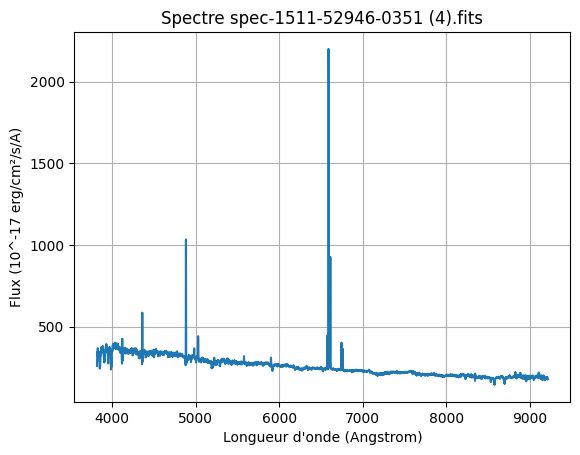

In [43]:
# Graphe
plt.plot(lam, flux) # plot axe x = lam axe y = flux
plt.xlabel("Longueur d'onde (Angstrom)") # Label axe x
plt.ylabel("Flux (10^-17 erg/cm²/s/A)") # Label axe y (unité astro)
plt.title(f"Spectre {filename}") # titre du graphe. f permet d'intégrer du python (entre accolades) a l'intérieur de la chaine
plt.grid(True) # grille sur le graphe
plt.show() # Montre le résultat

# Exportation des données au format dat compatible Visual Spec


In [50]:
# Créer un tableau 2D avec les colonnes 'lam' et 'flux'
data_to_export = np.column_stack((lam, flux))

# Définir le nom du fichier de sortie
output_filename = filename.replace('.fits', '.dat')

# Exporter les données vers un fichier .dat avec un espace comme séparateur et CRLF comme fin de ligne
np.savetxt(output_filename, data_to_export, fmt='%.10f', delimiter=' ', newline='\r\n')

print(f"Les données ont été exportées vers '{output_filename}'")

files.download(output_filename)

Les données ont été exportées vers 'spec-1511-52946-0351 (4).dat'
